In [1]:
# load packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.holtwinters import (
    SimpleExpSmoothing,
    Holt,
    ExponentialSmoothing
)
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, acf
# from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.signal import find_peaks
from itertools import product as iterproduct
from itertools import combinations as feat_combinations
from scipy.stats import pearsonr
from statsmodels.tsa.api import VAR
from statsmodels.stats.diagnostic import het_arch
from arch import arch_model
from itertools import combinations
from numpy.linalg import lstsq
from statsmodels.tsa.seasonal import seasonal_decompose
from itertools import product
import matplotlib.dates as mdates
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

In [2]:
# load data set
sales_data = pd.read_csv("sales_data.csv")

In [3]:
# convert to date time
sales_data["Date"] = pd.to_datetime(sales_data["Date"])
sales_data = sales_data.sort_values("Date")
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                76000 non-null  datetime64[ns]
 1   Store ID            76000 non-null  object        
 2   Product ID          76000 non-null  object        
 3   Category            76000 non-null  object        
 4   Region              76000 non-null  object        
 5   Inventory Level     76000 non-null  int64         
 6   Units Sold          76000 non-null  int64         
 7   Units Ordered       76000 non-null  int64         
 8   Price               76000 non-null  float64       
 9   Discount            76000 non-null  int64         
 10  Weather Condition   76000 non-null  object        
 11  Promotion           76000 non-null  int64         
 12  Competitor Pricing  76000 non-null  float64       
 13  Seasonality         76000 non-null  object        


## Creative Model

### Set Parameters and Prepare Data

In [25]:
RANDOM_STATE = 42
TARGET       = 'Units Sold'
SHORT_HORIZON = 5
LONG_HORIZON = 28
N_CV_ORIGINS = 15
CV_STEP_DAYS = 7

In [26]:
# # Use the store-category series from the main notebook so this creative model works on the same set of time series.
# # `store_cat` contains aggregated Units Sold by Date, Store ID and Category.

# sales_data = store_cat.copy()

# # Merge back the exogenous and metadata features from the original dataset if needed.
# # This preserves the same series definitions while providing Promotion, Discount, Competitor Pricing, Weather and Epidemic.
# meta_cols = ['Date', 'Store ID', 'Category', 'Promotion', 'Discount', 'Competitor Pricing', 'Weather Condition', 'Epidemic', 'Seasonality']
# # if 'df' in globals():
# #     exog_meta = df[meta_cols].drop_duplicates(subset=['Date', 'Store ID', 'Category'])
# #     sales_data = sales_data.merge(exog_meta, on=['Date', 'Store ID', 'Category'], how='left')

# # sales_data['Date'] = pd.to_datetime(sales_data['Date'])
# sales_data = df.sort_values(['Store ID', 'Category', 'Date']).reset_index(drop=True)
# sales_data['series_id'] = sales_data['Store ID'] + '_' + sales_data['Category']

print(f'Total rows: {len(sales_data):,}')
print(f'Date range: {sales_data["Date"].min().date()} to {sales_data["Date"].max().date()}')
print(f'Stores: {sorted(sales_data["Store ID"].unique())}')
print(f'Categories: {sales_data["Category"].nunique()}')

Total rows: 76,000
Date range: 2022-01-01 to 2024-01-30
Stores: ['S001', 'S002', 'S003', 'S004', 'S005']
Categories: 5


### Feature Engineering

We create three groups of features:
- **Lag features**: past values of Units Sold (lags 1, 2, 3, 7, 14, 21, 28). These give the model memory of recent demand.
- **Rolling statistics**: rolling means and standard deviations computed from past data. These capture recent demand trends and volatility.
- **Exogenous features**: Promotion, Discount, Competitor Pricing, Weather, Epidemic. These are all known ahead of time (promotions are planned, epidemic status is observable), so they are valid inputs for future forecasts.
- **Time features**: day of week, month, week of year. These help the model learn calendar-based patterns.
- **Static features**: Store ID, Category, Region. These let the model distinguish between different store-category series.


In [27]:
def create_lag_features(df, target_col="Units Sold"):
    """
    Creates lag and rolling features grouped by (Store ID, Category).
    No series_id column is required.
    """
    df = df.copy().sort_values(['Store ID', 'Category', 'Date'])
    
    # Group by store-category pair
    grp = df.groupby(['Store ID', 'Category'])[target_col]

    # Lag features
    for lag in [1, 2, 3, 7, 14, 21, 28]:
        df[f'lag_{lag}'] = grp.shift(lag)

    # Rolling means (shift 1 to avoid leakage)
    for window in [7, 14, 28]:
        df[f'rolling_mean_{window}'] = (
            grp.shift(1)
               .transform(lambda x: x.rolling(window, min_periods=1).mean())
        )

    # Rolling std (volatility)
    for window in [7, 14]:
        df[f'rolling_std_{window}'] = (
            grp.shift(1)
               .transform(lambda x: x.rolling(window, min_periods=2).std())
        )

    # Time features
    df['day_of_week']  = df['Date'].dt.dayofweek
    df['month']        = df['Date'].dt.month
    df['week_of_year'] = df['Date'].dt.isocalendar().week.astype(int)
    df['day_of_month'] = df['Date'].dt.day
    df['quarter']      = df['Date'].dt.quarter
    df['is_weekend']   = (df['Date'].dt.dayofweek >= 5).astype(int)

    # Label encode categorical features
    cat_cols = [
        'Store ID', 'Category', 'Region',
        'Weather Condition', 'Seasonality'
    ]
    cat_cols = [c for c in cat_cols if c in df.columns]

    encoders = {}
    for col in cat_cols:
        le = LabelEncoder()
        df[col + '_enc'] = le.fit_transform(df[col].astype(str))
        encoders[col] = le

    return df, encoders

sales_data, encoders = create_lag_features(sales_data)

static_features = [
    f'{col}_enc'
    for col in ['Store ID', 'Category', 'Region']
    if f'{col}_enc' in sales_data.columns
]

time_features = [
    'day_of_week', 'month', 'week_of_year',
    'day_of_month', 'quarter', 'is_weekend'
]

lag_features = [f'lag_{d}' for d in [1, 2, 3, 7, 14, 21, 28]]

rolling_features = [
    'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28',
    'rolling_std_7', 'rolling_std_14'
]

exog_features = [
    col for col in [
        'Promotion', 'Discount', 'Competitor Pricing',
        'Epidemic', 'Weather Condition_enc'
    ]
    if col in sales_data.columns
]

ALL_FEATURES = (
    static_features +
    time_features +
    lag_features +
    rolling_features +
    exog_features
)

### Train / Test Split

We hold out the **last 28 days** as a completely unseen test set. This is a strict temporal holdout: the model never sees any test data during training or hyperparameter tuning. The remaining data is used for training and cross-validation.

In [28]:
# Drop rows where lag features are NaN (first ~30 rows per series)
df_model = sales_data.dropna(subset=lag_features).reset_index(drop=True)

# Identify valid store-category series with enough history
valid_pairs = (
    df_model.groupby(['Store ID', 'Category'])
            .size()
            .loc[lambda x: x >= LONG_HORIZON]
            .index
)

# Remove short series
if len(valid_pairs) != df_model.groupby(['Store ID', 'Category']).ngroups:
    removed = df_model.groupby(['Store ID', 'Category']).ngroups - len(valid_pairs)
    print(f"Removing {removed} series with fewer than {LONG_HORIZON} observations after lagging.")

df_model = (
    df_model.set_index(['Store ID', 'Category'])
            .loc[valid_pairs]
            .reset_index()
)

# Split: last LONG_HORIZON rows per store-category → test
test_df = (
    df_model.groupby(['Store ID', 'Category'], group_keys=False)
            .tail(LONG_HORIZON)
            .reset_index(drop=True)
)

train_df = df_model.drop(test_df.index).reset_index(drop=True)

# Cutoff date
test_cutoff = train_df['Date'].max()

# Feature matrices
X_train = train_df[ALL_FEATURES]
y_train = train_df[TARGET]

X_test  = test_df[ALL_FEATURES]
y_test  = test_df[TARGET]

print(f"Training rows: {len(train_df):,}   ({train_df['Date'].min().date()} → {train_df['Date'].max().date()})")
print(f"Test rows    : {len(test_df):,}   ({test_df['Date'].min().date()} → {test_df['Date'].max().date()})")

n_series = train_df.groupby(['Store ID', 'Category']).ngroups
print(f"Training covers all {n_series} store-category series")

Training rows: 74,656   (2022-01-03 → 2024-01-30)
Test rows    : 672   (2024-01-03 → 2024-01-30)
Training covers all 24 store-category series


### Train the Global LightGBM Model

We use early stopping on a small validation slice (last 60 days of training) to prevent overfitting. The final model is then trained on all training data.

In [29]:
LGBM_PARAMS = {
    'objective'        : 'regression_l1',   # MAE loss
    'metric'           : 'mae',
    'learning_rate'    : 0.05,
    'num_leaves'       : 63,
    'min_child_samples': 20,
    'feature_fraction' : 0.8,
    'bagging_fraction' : 0.8,
    'bagging_freq'     : 5,
    'n_estimators'     : 1000,
    'random_state'     : RANDOM_STATE,
    'verbose'          : -1
}

# Use last 60 days of training as internal validation for early stopping
val_cutoff = test_cutoff - pd.Timedelta(days=60)

inner_train = train_df[train_df['Date'] <= val_cutoff]
inner_val   = train_df[train_df['Date'] >  val_cutoff]

print(f"Inner-train rows: {len(inner_train):,}")
print(f"Inner-val rows  : {len(inner_val):,}")

model_es = lgb.LGBMRegressor(**LGBM_PARAMS)

model_es.fit(
    inner_train[ALL_FEATURES], inner_train[TARGET],
    eval_set=[(inner_val[ALL_FEATURES], inner_val[TARGET])],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

best_n_estimators = model_es.best_iteration_
print(f"Best number of estimators from early stopping: {best_n_estimators}")

# Retrain on full training set using the best number of estimators
LGBM_PARAMS_FINAL = {**LGBM_PARAMS, 'n_estimators': best_n_estimators}

model = lgb.LGBMRegressor(**LGBM_PARAMS_FINAL)
model.fit(X_train, y_train)

print("Final model trained on full training set.")

Inner-train rows: 68,656
Inner-val rows  : 6,000
[100]	valid_0's l1: 25.6674
[200]	valid_0's l1: 25.4525
Best number of estimators from early stopping: 203
Final model trained on full training set.


### Evaluation Metrics

We use a mix of standard accuracy metrics and business-relevant metrics.

- **MAE / RMSE / MAPE**: standard error measures.
- **Bias**: whether the model systematically over- or under-forecasts.
- **Stockout Rate**: how often the model under-forecasts. In retail, under-forecasting leads to stockouts (lost sales). We want this to be low.
- **Overstock Rate**: how often the model over-forecasts by more than 20%. This leads to excess inventory and holding costs.
- **Directional Accuracy**: how often the model correctly predicts whether demand goes up or down. Useful for ordering decisions.

In [30]:
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    # MAE
    mae = np.mean(np.abs(y_true - y_pred))

    # RMSE
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

    # MAPE (avoid division by zero)
    safe_true = np.where(y_true == 0, np.nan, y_true)
    mape = np.nanmean(np.abs((y_true - y_pred) / safe_true)) * 100

    # WMAPE = sum(|error|) / sum(|actual|)
    denom = np.sum(np.abs(y_true))
    wmape = (np.sum(np.abs(y_true - y_pred)) / denom * 100) if denom != 0 else np.nan

    return {
        'MAE'   : round(mae,   2),
        'RMSE'  : round(rmse,  2),
        'MAPE'  : round(mape,  2),
        'WMAPE' : round(wmape, 2),
    }

### Test Set Results

In [31]:
# Full 28‑day test predictions
test_preds = model.predict(X_test)

# 28‑day metrics
m_28 = compute_metrics(y_test.values, test_preds)

# 5‑day metrics: first SHORT_HORIZON rows per store‑category
short_df = (
    test_df
    .sort_values(['Store ID', 'Category', 'Date'])
    .groupby(['Store ID', 'Category'], group_keys=False)
    .head(SHORT_HORIZON)
)

short_preds = model.predict(short_df[ALL_FEATURES])
m_5 = compute_metrics(short_df[TARGET].values, short_preds)

# Summary table
summary = pd.DataFrame([{
    'MAE_5d'   : m_5['MAE'],   'RMSE_5d'  : m_5['RMSE'],   'MAPE_5d'  : m_5['MAPE'],   'WMAPE_5d'  : m_5['WMAPE'],
    'MAE_28d'  : m_28['MAE'],  'RMSE_28d' : m_28['RMSE'],  'MAPE_28d' : m_28['MAPE'],  'WMAPE_28d' : m_28['WMAPE'],
}])

print("Overall test set metrics (all series):")
print(summary.T.rename(columns={0: 'Global LightGBM'}).to_string())

Overall test set metrics (all series):
           Global LightGBM
MAE_5d               25.03
RMSE_5d              32.94
MAPE_5d             126.98
WMAPE_5d             27.83
MAE_28d              22.75
RMSE_28d             30.64
MAPE_28d             48.68
WMAPE_28d            25.39


In [32]:
results = []

# Iterate through each store–category pair
for store, category in (
    test_df[['Store ID', 'Category']]
    .drop_duplicates()
    .sort_values(['Store ID', 'Category'])
    .values
):
    series_test = (
        test_df[(test_df['Store ID'] == store) &
                (test_df['Category'] == category)]
        .sort_values('Date')
    )

    # 28‑day predictions
    preds_28 = model.predict(series_test[ALL_FEATURES])

    # 5‑day predictions (first SHORT_HORIZON rows)
    short_test = series_test.head(SHORT_HORIZON)
    preds_5 = model.predict(short_test[ALL_FEATURES])

    # Metrics
    m_28 = compute_metrics(series_test[TARGET].values, preds_28)
    m_5  = compute_metrics(short_test[TARGET].values, preds_5)

    results.append({
        'Store'    : store,
        'Category' : category,
        'MAE_5d'   : m_5['MAE'],   'RMSE_5d'  : m_5['RMSE'],   'MAPE_5d'  : m_5['MAPE'],   'WMAPE_5d'  : m_5['WMAPE'],
        'MAE_28d'  : m_28['MAE'],  'RMSE_28d' : m_28['RMSE'],  'MAPE_28d' : m_28['MAPE'],  'WMAPE_28d' : m_28['WMAPE'],
    })

series_df = pd.DataFrame(results)

print("Per-series metrics (mean across all series):")
print(series_df.drop(columns=['Store', 'Category']).mean().round(2))
print()

print("Best 5 series by 28-day MAE:")
print(series_df.sort_values('MAE_28d').head(5).to_string(index=False))
print()

print("Worst 5 series by 28-day MAE:")
print(series_df.sort_values('MAE_28d', ascending=False).head(5).to_string(index=False))

Per-series metrics (mean across all series):
MAE_5d        25.02
RMSE_5d       30.61
MAPE_5d      126.52
WMAPE_5d      31.22
MAE_28d       22.75
RMSE_28d      29.86
MAPE_28d      48.65
WMAPE_28d     25.46
dtype: float64

Best 5 series by 28-day MAE:
Store    Category  MAE_5d  RMSE_5d  MAPE_5d  WMAPE_5d  MAE_28d  RMSE_28d  MAPE_28d  WMAPE_28d
 S002   Furniture    7.53     9.11    22.96     22.40    14.06     19.17     27.00      23.24
 S003 Electronics   16.52    22.33    47.83     19.12    15.98     20.91     20.89      16.31
 S004   Furniture   26.88    36.94    23.35     25.94    18.29     23.77     25.09      24.28
 S004    Clothing   19.08    34.48    46.80     22.72    18.47     26.55     33.13      21.59
 S001   Furniture   18.27    21.24    44.31     28.02    18.61     22.46     27.92      24.94

Worst 5 series by 28-day MAE:
Store    Category  MAE_5d  RMSE_5d  MAPE_5d  WMAPE_5d  MAE_28d  RMSE_28d  MAPE_28d  WMAPE_28d
 S004   Groceries   32.36    38.61    34.51     28.44    38.9

### Rolling Origin Cross-Validation

Rolling origin CV gives a more stable estimate of performance than a single holdout split. At each origin, we train on all data up to that point, then evaluate on the next 5 and 28 days. We use 15 origins spaced 7 days apart.

Note: the lag features at validation time are computed from actual observed values. This is the standard academic setup. In a live production system, you would need to forecast lag values recursively for multi-step horizons.

In [33]:
def rolling_origin_cv(
    df,
    feature_cols,
    target_col,
    params,
    n_origins=N_CV_ORIGINS,
    step_days=CV_STEP_DAYS,
    h_short=SHORT_HORIZON,
    h_long=LONG_HORIZON
):
    """
    Rolling-origin cross-validation for the global LightGBM model.
    Evaluates MAE for short and long horizons at each origin.
    """

    # Latest date allowed for training (exclude final test horizon)
    max_train_date = df['Date'].max() - pd.Timedelta(days=h_long)

    # End of the last CV origin
    end_origin = max_train_date - pd.Timedelta(days=h_long)

    # Start of the first CV origin
    start_origin = end_origin - pd.Timedelta(days=step_days * (n_origins - 1))

    # Generate origin dates
    cutoffs = pd.date_range(start=start_origin, end=end_origin, freq=f'{step_days}D')

    results = []

    for cutoff in cutoffs:
        # Training data up to the cutoff
        train_cv = df[df['Date'] <= cutoff].dropna(subset=feature_cols)

        # Short horizon validation window
        val_short = df[
            (df['Date'] > cutoff) &
            (df['Date'] <= cutoff + pd.Timedelta(days=h_short))
        ].dropna(subset=feature_cols)

        # Long horizon validation window
        val_long = df[
            (df['Date'] > cutoff) &
            (df['Date'] <= cutoff + pd.Timedelta(days=h_long))
        ].dropna(subset=feature_cols)

        # Skip invalid origins
        if len(train_cv) == 0 or len(val_short) == 0 or len(val_long) == 0:
            continue

        # Fit model
        m = lgb.LGBMRegressor(**params)
        m.fit(train_cv[feature_cols], train_cv[target_col])

        # Predictions
        pred_short = m.predict(val_short[feature_cols])
        pred_long  = m.predict(val_long[feature_cols])

        # Metrics
        mae_short = mean_absolute_error(val_short[target_col], pred_short)
        mae_long  = mean_absolute_error(val_long[target_col],  pred_long)

        results.append({
            'Origin' : cutoff.date(),
            'Horizon': f'{h_short}-day',
            'MAE'    : mae_short
        })
        results.append({
            'Origin' : cutoff.date(),
            'Horizon': f'{h_long}-day',
            'MAE'    : mae_long
        })

        print(
            f'  Origin {cutoff.date()}: '
            f'MAE {h_short}-day = {mae_short:.2f}, '
            f'MAE {h_long}-day = {mae_long:.2f}'
        )

    return pd.DataFrame(results)

print('Running rolling origin cross-validation...')
cv_results = rolling_origin_cv(df_model, ALL_FEATURES, TARGET, LGBM_PARAMS_FINAL)

print('\nCV Summary (mean MAE per horizon):')
cv_summary = cv_results.groupby('Horizon')['MAE'].agg(['mean', 'std', 'min', 'max']).round(2)
print(cv_summary)

Running rolling origin cross-validation...
  Origin 2023-08-29: MAE 5-day = 26.06, MAE 28-day = 25.52
  Origin 2023-09-05: MAE 5-day = 24.93, MAE 28-day = 25.10
  Origin 2023-09-12: MAE 5-day = 25.53, MAE 28-day = 24.43
  Origin 2023-09-19: MAE 5-day = 25.86, MAE 28-day = 22.69
  Origin 2023-09-26: MAE 5-day = 23.82, MAE 28-day = 21.08
  Origin 2023-10-03: MAE 5-day = 24.54, MAE 28-day = 21.72
  Origin 2023-10-10: MAE 5-day = 17.48, MAE 28-day = 22.11
  Origin 2023-10-17: MAE 5-day = 19.06, MAE 28-day = 24.25
  Origin 2023-10-24: MAE 5-day = 28.33, MAE 28-day = 26.19
  Origin 2023-10-31: MAE 5-day = 26.14, MAE 28-day = 25.88
  Origin 2023-11-07: MAE 5-day = 26.32, MAE 28-day = 26.27
  Origin 2023-11-14: MAE 5-day = 27.06, MAE 28-day = 26.61
  Origin 2023-11-21: MAE 5-day = 25.07, MAE 28-day = 27.28
  Origin 2023-11-28: MAE 5-day = 26.62, MAE 28-day = 27.86
  Origin 2023-12-05: MAE 5-day = 27.56, MAE 28-day = 25.90

CV Summary (mean MAE per horizon):
          mean   std    min    max
H

### Visualisations

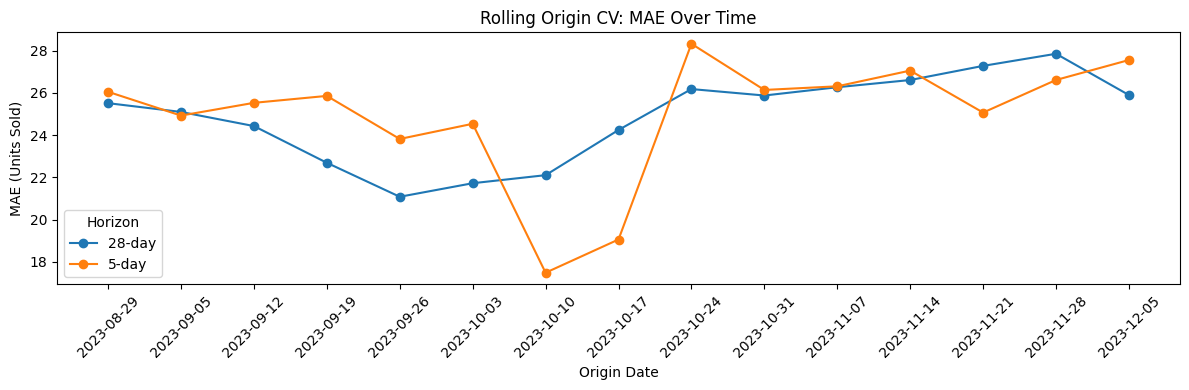

In [34]:
# --- Plot 1: Rolling origin CV MAE over time ---
fig, ax = plt.subplots(figsize=(12, 4))
for horizon, grp in cv_results.groupby('Horizon'):
    ax.plot(grp['Origin'].astype(str), grp['MAE'], marker='o', label=horizon)

ax.set_title('Rolling Origin CV: MAE Over Time')
ax.set_xlabel('Origin Date')
ax.set_ylabel('MAE (Units Sold)')
ax.legend(title='Horizon')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

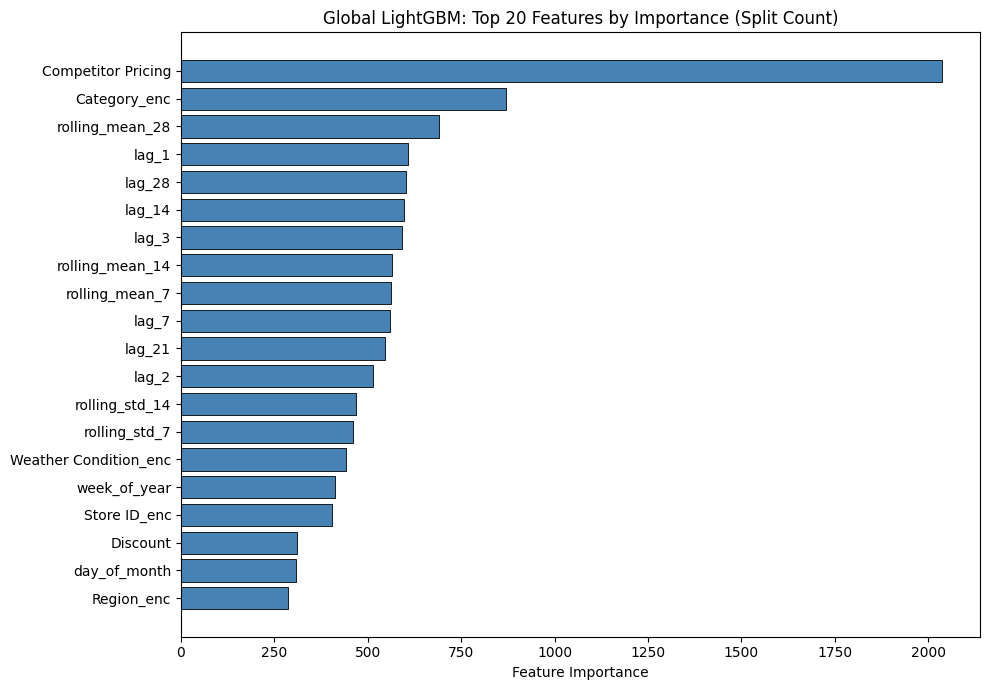

In [35]:
# Align feature names with model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'Importance': model.feature_importances_
})

# Sort and keep top 20
importance_df = (
    importance_df
    .sort_values('Importance', ascending=False)
    .head(20)
    .iloc[::-1]   # reverse for top-down barh
)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    importance_df['Feature'],
    importance_df['Importance'],
    color='steelblue',
    edgecolor='black',
    linewidth=0.6
)

ax.set_title('Global LightGBM: Top 20 Features by Importance (Split Count)')
ax.set_xlabel('Feature Importance')

plt.tight_layout()
plt.show()

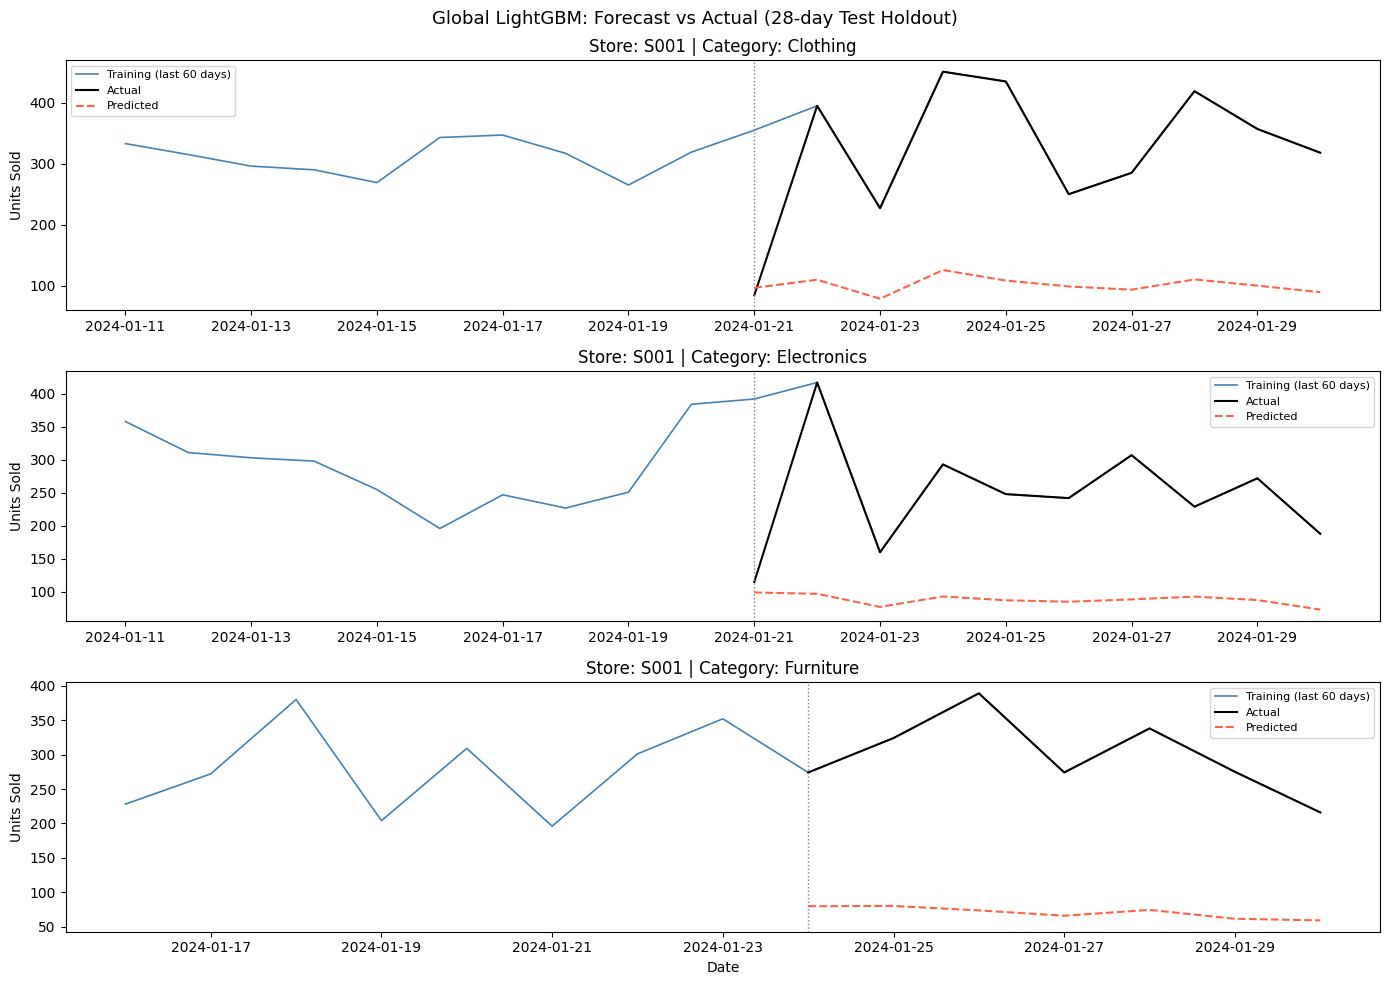

In [42]:
# Pick 3 sample store–category pairs
sample_pairs = (
    test_df[['Store ID', 'Category']]
    .drop_duplicates()
    .sort_values(['Store ID', 'Category'])
    .head(3)
    .values
)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

for ax, (store, category) in zip(axes, sample_pairs):

    # Last 60 days of training for this series
    train_tail = (
        train_df[(train_df['Store ID'] == store) &
                 (train_df['Category'] == category)]
        .sort_values('Date')
        .tail(60)
    )

    # Full 28‑day test window
    test_series = (
        test_df[(test_df['Store ID'] == store) &
                (test_df['Category'] == category)]
        .sort_values('Date')
    )

    # Predictions
    preds = model.predict(test_series[ALL_FEATURES])

    # --- FIX: aggregate INSIDE the loop ---
    train_tail_agg = (
        train_tail.groupby('Date', as_index=False)[TARGET].sum()
    )

    test_series_agg = (
        test_series.groupby('Date', as_index=False)[TARGET].sum()
    )

    preds_agg = (
        pd.DataFrame({'Date': test_series['Date'], 'Pred': preds})
        .groupby('Date', as_index=False)['Pred'].mean()
    )

    # --- Plot ---
    ax.plot(train_tail_agg['Date'], train_tail_agg[TARGET],
            color='steelblue', label='Training (last 60 days)', linewidth=1.2)

    ax.plot(test_series_agg['Date'], test_series_agg[TARGET],
            color='black', label='Actual', linewidth=1.5)

    ax.plot(preds_agg['Date'], preds_agg['Pred'],
            color='tomato', linestyle='--', label='Predicted', linewidth=1.5)

    # Vertical line marking start of test period
    ax.axvline(test_series_agg['Date'].min(), color='grey', linestyle=':', linewidth=1)

    ax.set_title(f'Store: {store} | Category: {category}')
    ax.set_ylabel('Units Sold')
    ax.legend(fontsize=8)

axes[-1].set_xlabel('Date')
fig.suptitle('Global LightGBM: Forecast vs Actual (28-day Test Holdout)', fontsize=13)
plt.tight_layout()
plt.show()

### Business-Relevant Metric: Asymmetric Cost

Stockouts and overstock are not equally costly in retail. A stockout means a lost sale (revenue loss). Excess inventory means holding costs and potential markdowns. We assign a penalty ratio of 2:1 (under-forecast costs twice as much as over-forecast) and compute a weighted cost metric. This is a custom business metric that goes beyond standard MAE.

In [38]:
# --- Asymmetric cost benchmark ---

def asymmetric_cost(y_true, y_pred, under_penalty=2.0, over_penalty=1.0):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    errors = y_pred - y_true
    cost = np.where(
        errors < 0,
        under_penalty * np.abs(errors),
        over_penalty  * np.abs(errors)
    )
    return np.mean(cost)

# Naive seasonal benchmark: use lag_7 as forecast
naive_preds = test_df['lag_7'].values

# Align actuals and naive predictions (remove NaNs)
mask = ~np.isnan(naive_preds)
naive_actuals = y_test.values[mask]
naive_forecast = naive_preds[mask]

# Compute costs
lgbm_cost = asymmetric_cost(y_test.values, test_preds)
naive_cost = asymmetric_cost(naive_actuals, naive_forecast)

improvement = (naive_cost - lgbm_cost) / naive_cost * 100

print(f'Asymmetric Cost (2:1 penalty) -- Global LightGBM : {lgbm_cost:.2f}')
print(f'Asymmetric Cost (2:1 penalty) -- Naive Seasonal  : {naive_cost:.2f}')
print(f'Improvement over naive        : {improvement:.1f}%')

Asymmetric Cost (2:1 penalty) -- Global LightGBM : 35.79
Asymmetric Cost (2:1 penalty) -- Naive Seasonal  : 57.97
Improvement over naive        : 38.3%


### Summary

The Global LightGBM model:
- Trains a single model across all 100 store-product series, enabling cross-series learning.
- Uses lag features, rolling statistics, time features, and exogenous variables that are known ahead of time (promotions, discounts, epidemic status).
- Produces point forecasts for both short (5-day) and long (28-day) horizons.
- Is fully automatic: no manual intervention is needed per series.

**Key limitation:** For the 28-day horizon, weather and epidemic status may not be fully known in advance. In that case, average historical values per month can be used as a proxy, which slightly reduces accuracy but keeps the model practically deployable.

